In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv


In [2]:
import pandas as pd
import numpy as np
import os

df = pd.read_csv("/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# Check what files are available
for f in os.listdir('/kaggle/input/datasets/mashlyn/online-retail-ii-uci/'):
    print(f)

online_retail_II.csv


In [4]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Clean Dataset

In [5]:
print("Before cleaning:", df.shape)
print("Null Customer IDs:", df['Customer ID'].isnull().sum())
print("Cancelled orders:", df[df['Invoice'].astype(str).str.startswith('C')].shape[0])

Before cleaning: (1067371, 8)
Null Customer IDs: 243007
Cancelled orders: 19494


In [6]:
# Remove cancelled orders, nulls, and bad values
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df.dropna(subset=['Customer ID'])
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

In [7]:
# Fix data types
df['Customer ID'] = df['Customer ID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['Price']

In [8]:
print("\nAfter cleaning:", df.shape)
print("Date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())
print("Unique customers:", df['Customer ID'].nunique())


After cleaning: (805549, 9)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5878


# Sql queries

In [9]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('retail', conn, index=False, if_exists='replace')

def sql(query):
    return pd.read_sql_query(query, conn)

print("Loaded into SQLite!")

Loaded into SQLite!


In [10]:
# Query 1 — Overall business summary
print(sql("""
    SELECT 
        ROUND(SUM(TotalPrice), 2) as Total_Revenue,
        COUNT(DISTINCT "Customer ID") as Unique_Customers,
        COUNT(DISTINCT Invoice) as Total_Orders
    FROM retail
"""))

   Total_Revenue  Unique_Customers  Total_Orders
0    17743429.18              5878         36969


In [11]:
# Query 2 — Top 10 customers by revenue
print(sql("""
    SELECT 
        "Customer ID",
        ROUND(SUM(TotalPrice), 2) as Revenue,
        COUNT(DISTINCT Invoice) as Orders
    FROM retail
    GROUP BY "Customer ID"
    ORDER BY Revenue DESC
    LIMIT 10
"""))

   Customer ID    Revenue  Orders
0        18102  608821.65     145
1        14646  528602.52     151
2        14156  313946.37     156
3        14911  295972.63     398
4        17450  246973.09      51
5        13694  196482.81     143
6        17511  175603.55      60
7        16446  168472.50       2
8        16684  147142.77      55
9        12415  144458.37      28


In [12]:
# Query 3 — Revenue by country
print(sql("""
    SELECT 
        Country,
        ROUND(SUM(TotalPrice), 2) as Revenue,
        COUNT(DISTINCT "Customer ID") as Customers
    FROM retail
    GROUP BY Country
    ORDER BY Revenue DESC
    LIMIT 10
"""))

          Country      Revenue  Customers
0  United Kingdom  14723147.52       5350
1            EIRE    621631.11          5
2     Netherlands    554232.34         22
3         Germany    431262.46        107
4          France    355257.47         95
5       Australia    169968.11         15
6           Spain    109178.53         41
7     Switzerland    100365.34         22
8          Sweden     91549.72         19
9         Denmark     69862.19         12


In [13]:
df.to_csv('/kaggle/working/retail_cleaned.csv', index=False)
print("Saved!")

Saved!


# Calculate RFM values

In [14]:
df = pd.read_csv('/kaggle/working/retail_cleaned.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['Price']

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date:",reference_date)

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)
print(rfm.describe().round(2))
rfm.head(10)

Reference date: 2011-12-10 12:50:00
       Customer ID  Recency  Frequency   Monetary
count      5878.00  5878.00    5878.00    5878.00
mean      15315.31   201.33       6.29    3018.62
std        1715.57   209.34      13.01   14737.73
min       12346.00     1.00       1.00       2.95
25%       13833.25    26.00       1.00     348.76
50%       15314.50    96.00       3.00     898.92
75%       16797.75   380.00       7.00    2307.09
max       18287.00   739.00     398.00  608821.65


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40
5,12351,375,1,300.93
6,12352,36,10,2849.84
7,12353,204,2,406.76
8,12354,232,1,1079.40
9,12355,214,2,947.61


### Recency is in days — lower is better (bought recently). Frequency = number of unique orders. Monetary = total £ spent.

In [15]:
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5])

rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print(rfm[['Customer ID','Recency','Frequency','Monetary',
           'R_Score','F_Score','M_Score','RFM_Score']].head(10))
print("\nRFM Score range:", rfm['RFM_Score'].min(), "to", rfm['RFM_Score'].max())

   Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0        12346      326         12  77556.46        2        5        5   
1        12347        2          8   5633.32        5        4        5   
2        12348       75          5   2019.40        3        4        4   
3        12349       19          4   4428.69        5        3        5   
4        12350      310          1    334.40        2        1        2   
5        12351      375          1    300.93        2        1        2   
6        12352       36         10   2849.84        4        5        4   
7        12353      204          2    406.76        2        2        2   
8        12354      232          1   1079.40        2        1        3   
9        12355      214          2    947.61        2        2        3   

   RFM_Score  
0         12  
1         14  
2         11  
3         13  
4          5  
5          5  
6         13  
7          6  
8          6  
9          7  

RFM Scor

In [16]:
def segment(row):
    score = row['RFM_Score']
    r     = row['R_Score']
    f     = row['F_Score']
    if score >= 13:              
        return 'Champions'
    elif score >= 10:            
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:      
        return 'Promising'
    elif r >= 3 and score >= 7:  
        return 'Potential Loyalists'
    elif r <= 2 and score >= 7:  
        return 'At Risk'
    elif r <= 2 and f >= 4:      
        return 'Cannot Lose Them'
    else:                        
        return 'Lost'

rfm['Segment'] = rfm.apply(segment, axis=1)

segment_summary = rfm.groupby('Segment').agg(
    Customers = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean')
).round(2).sort_values('Customers', ascending=False)

print(segment_summary)

                     Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Segment                                                                 
Lost                      1704       424.26           1.26        310.95
Loyal Customers           1355        95.95           5.58       2309.96
Champions                 1297        25.86          17.94       9877.98
At Risk                    653       365.61           3.36       1216.79
Potential Loyalists        479        94.66           2.61        674.36
Promising                  388        29.99           1.40        396.44
Cannot Lose Them             2       606.00           6.00        222.00


In [17]:
rfm.to_csv('/kaggle/working/rfm_scores.csv', index=False)
print("Saved! Shape:", rfm.shape)
print("\nSegment breakdown:")
print(rfm['Segment'].value_counts())

Saved! Shape: (5878, 9)

Segment breakdown:
Segment
Lost                   1704
Loyal Customers        1355
Champions              1297
At Risk                 653
Potential Loyalists     479
Promising               388
Cannot Lose Them          2
Name: count, dtype: int64


# Load RFM data & scale features

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rfm = pd.read_csv('/kaggle/working/rfm_scores.csv')

In [19]:
# Select only R, F, M values for clustering
X = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Scale so all features have equal weight
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original scale:")
print(X.describe().round(2))
print("\nScaled (mean~0, std~1):")
print(pd.DataFrame(X_scaled, columns=['Recency','Frequency','Monetary']).describe().round(2))

Original scale:
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    3018.62
std     209.34      13.01   14737.73
min       1.00       1.00       2.95
25%      26.00       1.00     348.76
50%      96.00       3.00     898.92
75%     380.00       7.00    2307.09
max     739.00     398.00  608821.65

Scaled (mean~0, std~1):
       Recency  Frequency  Monetary
count  5878.00    5878.00   5878.00
mean     -0.00      -0.00     -0.00
std       1.00       1.00      1.00
min      -0.96      -0.41     -0.20
25%      -0.84      -0.41     -0.18
50%      -0.50      -0.25     -0.14
75%       0.85       0.05     -0.05
max       2.57      30.11     41.11


# Find optimal K using Elbow method

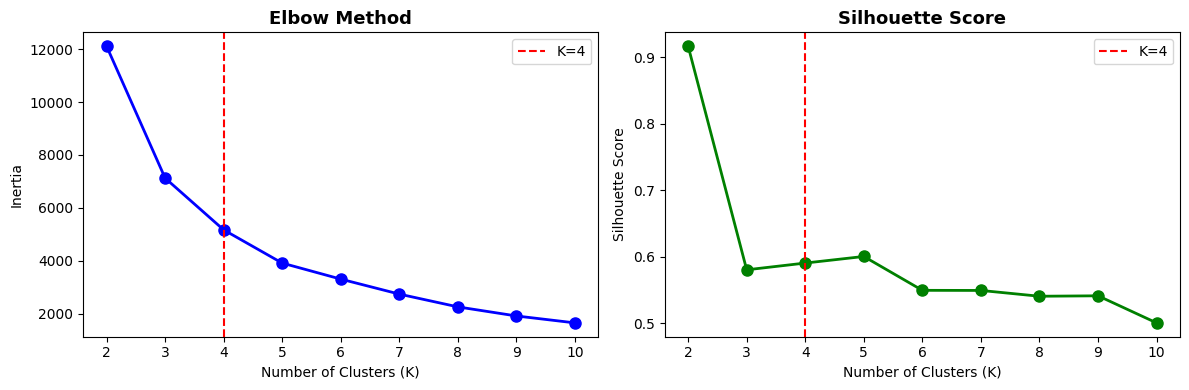

In [20]:
inertia = []
silhouette = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.axvline(x=4, color='red', linestyle='--', label='K=4')
ax1.legend()

ax2.plot(K_range, silhouette, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score', fontsize=13, fontweight='bold')
ax2.axvline(x=4, color='red', linestyle='--', label='K=4')
ax2.legend()

plt.tight_layout()
plt.savefig('elbow_chart.png', bbox_inches='tight', dpi=120)
plt.show()

# Train K-Means with K=4

In [21]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km.fit_predict(X_scaled)

cluster_summary = rfm.groupby('Cluster').agg(
    Customers  = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean')
).round(2)

print(cluster_summary)
print("\nSilhouette Score:", round(silhouette_score(X_scaled, rfm['Cluster']), 3))

         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                     
0             1998       463.03           2.21        765.24
1             3841        67.01           7.31       3009.40
2               35        25.94         103.71      83086.08
3                4         3.50         212.50     436835.79

Silhouette Score: 0.591


```text
Cluster 3 → VIP Whales      (4 customers, avg £436K, buy 212x!)
Cluster 2 → Champions       (35 customers, avg £83K, buy 103x)
Cluster 1 → Loyal Customers (3,841 customers, avg £3K, recent)
Cluster 0 → Lost / Inactive (1,998 customers, avg £765, 463 days ago)

This data revealed a 4th unexpected segment — Ultra VIP Whales. Only 4 customers  but they're responsible for a massive chunk of revenue. This is a golden finding  for this project! ```

# Label clusters with business names

In [22]:
# Map cluster numbers to business labels
# based on your cluster_summary output
cluster_labels = {
    0: 'Lost / Inactive',
    1: 'Loyal Customers',
    2: 'Champions',
    3: 'VIP Whales'
}
# NOTE: your cluster numbers may differ!
# Assign labels based on Avg_Monetary & Avg_Recency:
# Highest Monetary + Lowest Recency → Champions
# Highest Frequency + Medium Monetary → Loyal
# High Recency days (bought long ago) → At Risk / Lost

rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_labels)

print(rfm['Cluster_Label'].value_counts())
print("\nSample VIP Whales:")
print(rfm[rfm['Cluster_Label']=='VIP Whales'][
    ['Customer ID','Recency','Frequency','Monetary']
])

Cluster_Label
Loyal Customers    3841
Lost / Inactive    1998
Champions            35
VIP Whales            4
Name: count, dtype: int64

Sample VIP Whales:
      Customer ID  Recency  Frequency   Monetary
1789        14156       10        156  313946.37
2277        14646        2        151  528602.52
2538        14911        1        398  295972.63
5692        18102        1        145  608821.65


# Visualize clusters & save

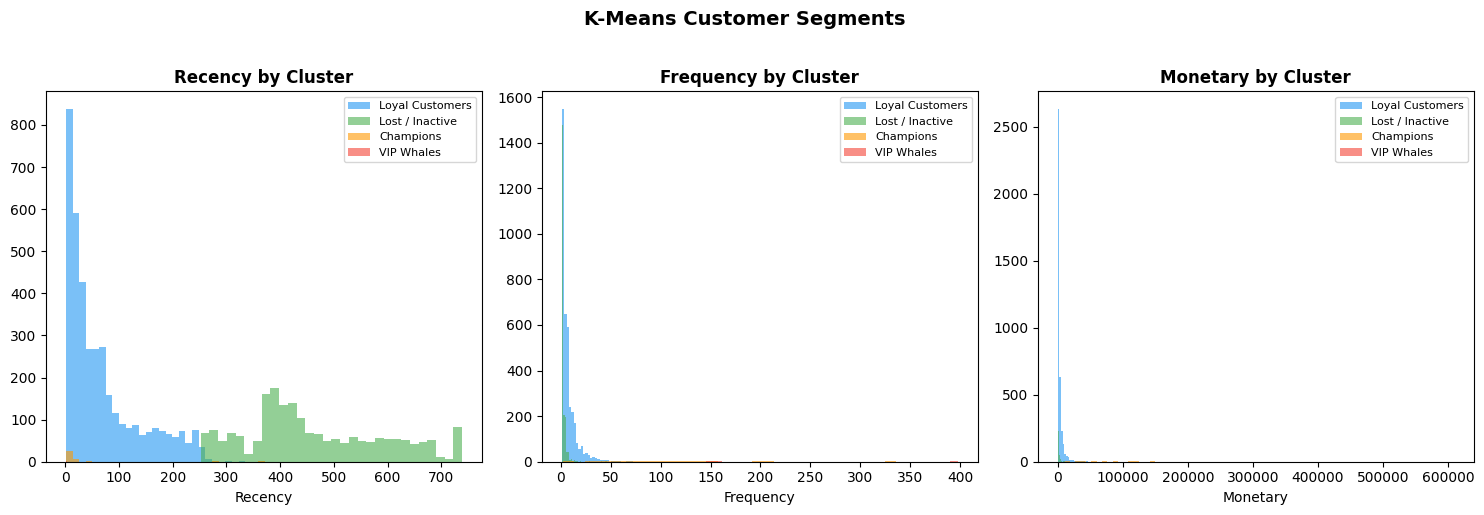

Saved! Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment', 'Cluster', 'Cluster_Label']


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#2196F3','#4CAF50','#FF9800','#F44336']

for i, (ax, col) in enumerate(zip(axes, ['Recency','Frequency','Monetary'])):
    for j, label in enumerate(rfm['Cluster_Label'].unique()):
        data = rfm[rfm['Cluster_Label']==label][col]
        ax.hist(data, alpha=0.6, label=label, color=colors[j], bins=30)
    ax.set_title(f'{col} by Cluster', fontweight='bold')
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

plt.suptitle('K-Means Customer Segments', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cluster_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

rfm.to_csv('/kaggle/working/rfm_clustered.csv', index=False)
print("Saved! Columns:", rfm.columns.tolist())

# Install Prophet & prepare data

In [24]:
!pip install prophet -q

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

In [26]:
df = pd.read_csv('/kaggle/working/retail_cleaned.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Aggregate to daily revenue
daily_sales = df.groupby(
    df['InvoiceDate'].dt.date
)['TotalPrice'].sum().reset_index()

daily_sales.columns = ['ds', 'y']
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

print("Daily sales shape:", daily_sales.shape)
print("Date range:", daily_sales['ds'].min(), "to", daily_sales['ds'].max())
print("\nSample:")
print(daily_sales.tail(5))

Daily sales shape: (604, 2)
Date range: 2009-12-01 00:00:00 to 2011-12-09 00:00:00

Sample:
            ds          y
599 2011-12-05   58202.21
600 2011-12-06   46144.04
601 2011-12-07   69354.21
602 2011-12-08   50519.41
603 2011-12-09  184367.28


# Plot historical sales trend

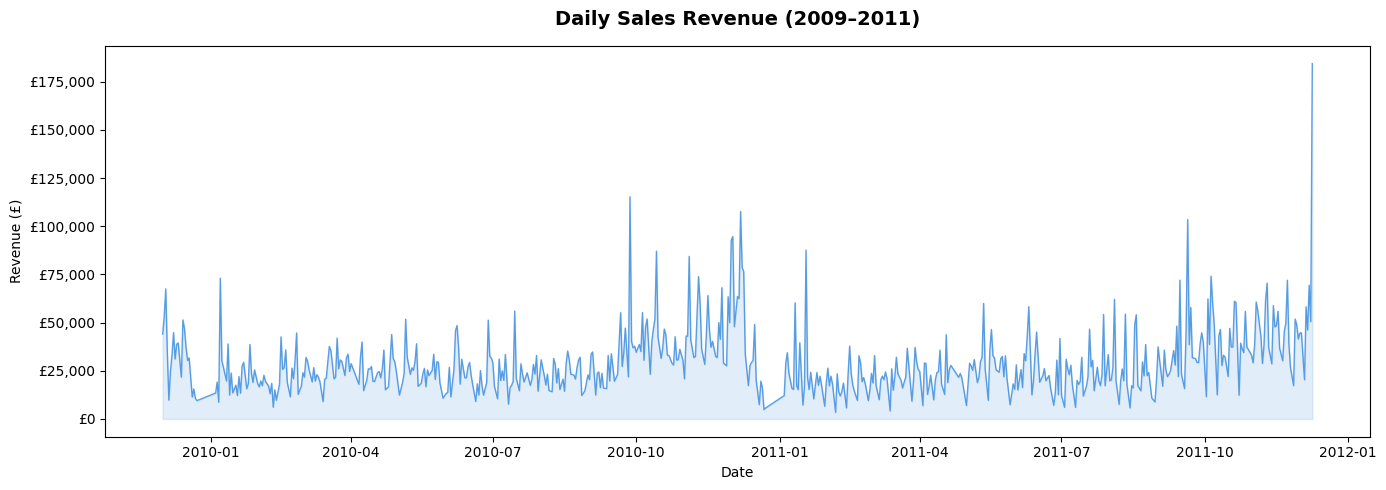

Peak day: 2011-12-09 → £184,367


In [27]:

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_sales['ds'], daily_sales['y'],
        color='#378ADD', linewidth=1, alpha=0.8)
ax.fill_between(daily_sales['ds'], daily_sales['y'],
                alpha=0.15, color='#378ADD')
ax.set_title('Daily Sales Revenue (2009–2011)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)
plt.tight_layout()
plt.savefig('daily_sales_history.png', bbox_inches='tight', dpi=120)
plt.show()

print("Peak day:", daily_sales.loc[daily_sales['y'].idxmax(), 'ds'].date(),
      "→ £{:,.0f}".format(daily_sales['y'].max()))

# Train Prophet model

In [28]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model.fit(daily_sales)
print("Model trained successfully!")

future = model.make_future_dataframe(periods=90)
print("Future dataframe shape:", future.shape)
print("Forecasting up to:", future['ds'].max().date())

04:41:31 - cmdstanpy - INFO - Chain [1] start processing
04:41:31 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully!
Future dataframe shape: (694, 1)
Forecasting up to: 2012-03-08


# Generate & plot forecast

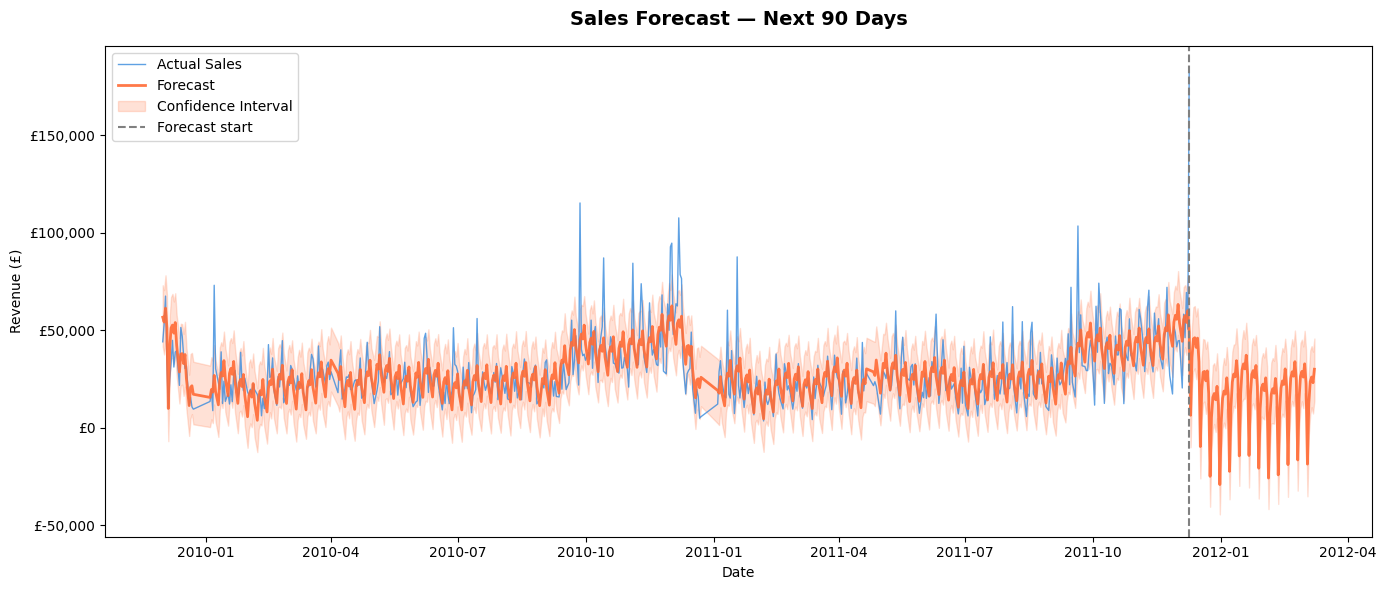


Next 90-day forecast summary:
Predicted Total Revenue: £1,578,147
Best Case (upper):        £3,020,944
Worst Case (lower):       £144,698


In [29]:
forecast = model.predict(future)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_sales['ds'], daily_sales['y'],
        color='#378ADD', linewidth=1, label='Actual Sales', alpha=0.8)
ax.plot(forecast['ds'], forecast['yhat'],
        color='#FF6B35', linewidth=2, label='Forecast', alpha=0.9)
ax.fill_between(forecast['ds'],
                forecast['yhat_lower'],
                forecast['yhat_upper'],
                alpha=0.2, color='#FF6B35', label='Confidence Interval')
ax.axvline(x=daily_sales['ds'].max(), color='gray',
           linestyle='--', linewidth=1.5, label='Forecast start')
ax.set_title('Sales Forecast — Next 90 Days',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)
ax.legend()
plt.tight_layout()
plt.savefig('sales_forecast.png', bbox_inches='tight', dpi=120)
plt.show()

next_90 = forecast[forecast['ds'] > daily_sales['ds'].max()]
print("\nNext 90-day forecast summary:")
print(f"Predicted Total Revenue: £{next_90['yhat'].sum():,.0f}")
print(f"Best Case (upper):        £{next_90['yhat_upper'].sum():,.0f}")
print(f"Worst Case (lower):       £{next_90['yhat_lower'].sum():,.0f}")

# Plot seasonality components & save

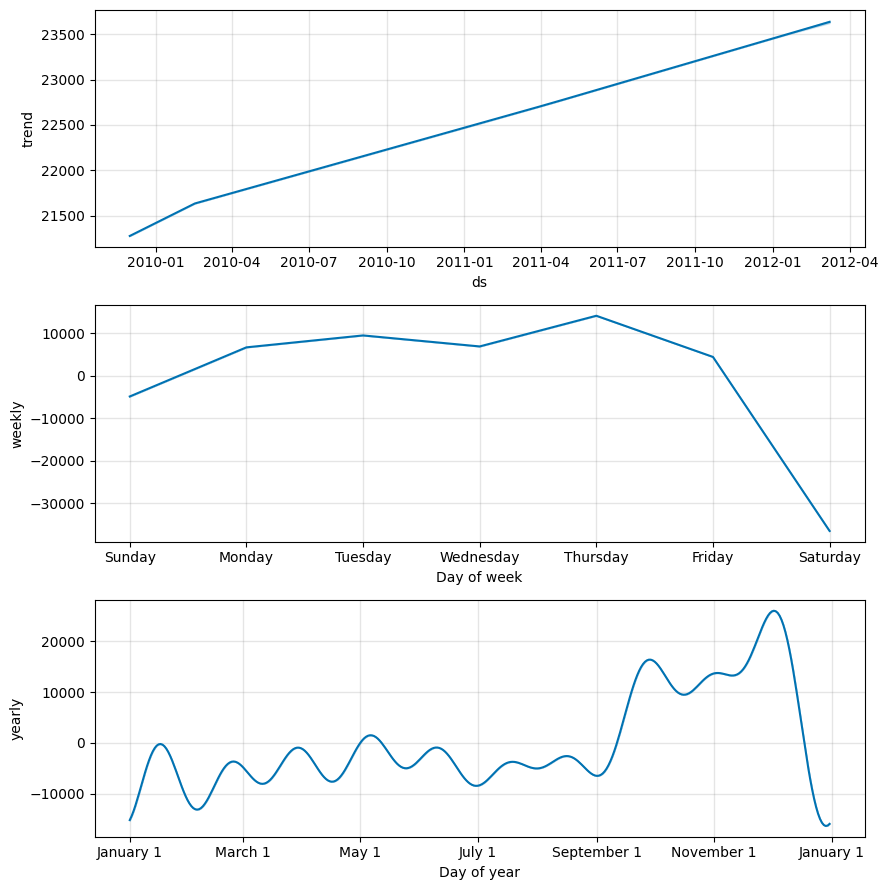

Forecast saved!


In [30]:
fig2 = model.plot_components(forecast)
plt.savefig('forecast_components.png', bbox_inches='tight', dpi=120)
plt.show()

# Save forecast to CSV
forecast[['ds','yhat','yhat_lower','yhat_upper']].to_csv(
    '/kaggle/working/sales_forecast.csv', index=False
)
print("Forecast saved!")

In [32]:
# Save everything needed for Power BI and GitHub
import shutil

rfm = pd.read_csv('/kaggle/working/rfm_clustered.csv')
forecast = pd.read_csv('/kaggle/working/sales_forecast.csv')

print("Files ready in /kaggle/working/:")
import os
for f in os.listdir('/kaggle/working/'):
    size = os.path.getsize(f'/kaggle/working/{f}')
    print(f"  {f} — {size/1024:.1f} KB")

Files ready in /kaggle/working/:
  rfm_scores.csv — 217.2 KB
  rfm_clustered.csv — 320.3 KB
  cluster_distribution.png — 60.8 KB
  sales_forecast.png — 223.6 KB
  retail_cleaned.csv — 75556.6 KB
  forecast_components.png — 95.5 KB
  elbow_chart.png — 53.1 KB
  daily_sales_history.png — 128.9 KB
  sales_forecast.csv — 45.0 KB
  .virtual_documents — 4.0 KB
